In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
file_path = r"c:\\Users\\mbeng\\Documents\\WEEK 10\\data_ready.csv"
df = pd.read_csv(file_path)
target_col = "Attrition"

if target_col not in df.columns:
    raise ValueError(f"{target_col} column not found in dataset")

print(f"Rows: {len(df)}")
print(f"Target column: {target_col}")

Rows: 1679
Target column: Attrition


In [6]:
# Distribution table: employees who stayed vs left
counts = df[target_col].value_counts()
percent = (df[target_col].value_counts(normalize=True) * 100).round(2)
distribution = pd.DataFrame({"Count": counts, "Percent": percent})

display(distribution)

imbalance_ratio = counts.max() / counts.min()
print(f"Imbalance ratio (majority/minority): {imbalance_ratio:.2f}")

,Count,Percent
Attrition,,
No,1480,88.15
Yes,199,11.85


Imbalance ratio (majority/minority): 7.44


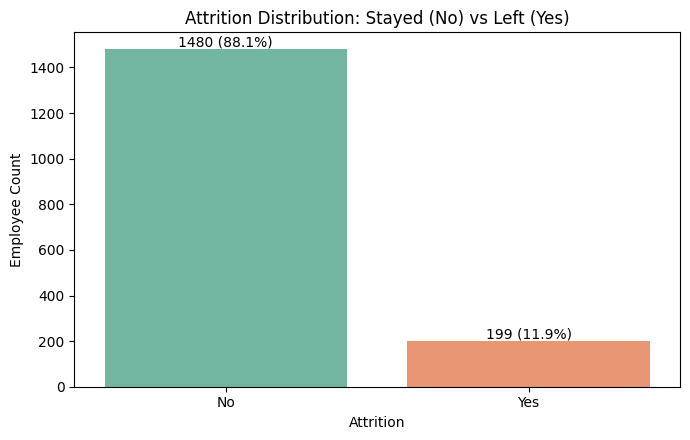

In [21]:
# Bar chart of Attrition classes
plt.figure(figsize=(7, 4.5))
ax = sns.countplot(data=df, x=target_col, hue=target_col, palette="Set2", legend=False, order=counts.index.tolist())
plt.title("Attrition Distribution: Stayed (No) vs Left (Yes)")
plt.xlabel("Attrition")
plt.ylabel("Employee Count")

total = counts.sum()
for p in ax.patches:
    value = int(p.get_height())
    pct = 100 * value / total
    ax.annotate(f"{value} ({pct:.1f}%)", (p.get_x() + p.get_width() / 2, p.get_height()), ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [3]:
# Are classes balanced?
majority_class = counts.idxmax()
minority_class = counts.idxmin()
majority_pct = percent.loc[majority_class]
minority_pct = percent.loc[minority_class]

if majority_pct <= 60:
    balance_status = "fairly balanced"
elif majority_pct <= 80:
    balance_status = "moderately imbalanced"
else:
    balance_status = "strongly imbalanced"

print(f"Class balance result: {balance_status}")
print(f"Majority class: {majority_class} ({majority_pct}%)")
print(f"Minority class: {minority_class} ({minority_pct}%)")

Class balance result: strongly imbalanced
Majority class: No (88.15%)
Minority class: Yes (11.85%)


In [23]:
# Final answer for the business question
print(
    "Using the employee dataset, the target classes are not balanced: "
    f"Attrition=No is {percent.loc['No']}% and Attrition=Yes is {percent.loc['Yes']}%. "
    "This indicates class imbalance and should be considered when building the prediction model."
)

Using the employee dataset, the target classes are not balanced: Attrition=No is 88.15% and Attrition=Yes is 11.85%. This indicates class imbalance and should be considered when building the prediction model.


In [7]:
# One-hot encode nominal features for modeling
nominal_cols = [
    "BusinessTravel", "Department", "EducationField", "Gender",
    "JobRole", "MaritalStatus", "OverTime", "Shift"
 ]
nominal_cols = [c for c in nominal_cols if c in df.columns]

X = df.drop(columns=["Attrition", "Over18", "EmployeeCount", "StandardHours"], errors="ignore")
y = df["Attrition"].map({"No": 0, "Yes": 1})

X_encoded = pd.get_dummies(
    X,
    columns=nominal_cols,
    drop_first=False,
    dummy_na=False
 )

print("Nominal columns one-hot encoded:", nominal_cols)
print("Encoded feature matrix shape:", X_encoded.shape)
display(X_encoded.head())

Nominal columns one-hot encoded: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime', 'Shift']
Encoded feature matrix shape: (1679, 57)


,EmployeeID,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,MaritalStatus_Married,MaritalStatus_Single,OverTime_No,OverTime_Unknown,OverTime_Yes,Shift_-1.0,Shift_0.0,Shift_1.0,Shift_2.0,Shift_3.0
0,1313919,41,1102,1,2,2.0,94,3,2.0,4,...,False,True,False,False,True,False,True,False,False,False
1,1200302,49,279,8,1,3.0,61,2,2.0,2,...,True,False,True,False,False,False,False,True,False,False
2,1060315,37,1373,2,2,4.0,92,2,1.0,3,...,False,True,False,False,True,False,True,False,False,False
3,1272912,33,1392,3,4,4.0,56,3,1.0,3,...,True,False,False,False,True,False,True,False,False,False
4,1414939,27,591,2,1,1.0,40,3,1.0,2,...,True,False,True,False,False,False,False,True,False,False


In [8]:
from sklearn.model_selection import train_test_split

# Use a stratified split so the strong class imbalance is preserved in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

train_dist = y_train.value_counts(normalize=True).sort_index().mul(100).round(2)
test_dist = y_test.value_counts(normalize=True).sort_index().mul(100).round(2)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Test set shape: {X_test.shape}, {y_test.shape}")
print("\nTarget distribution (%)")
print("Train:")
print(train_dist.rename(index={0: 'No', 1: 'Yes'}))
print("\nTest:")
print(test_dist.rename(index={0: 'No', 1: 'Yes'}))

Training set shape: (1343, 57), (1343,)
Test set shape: (336, 57), (336,)

Target distribution (%)
Train:
Attrition
No     88.16
Yes    11.84
Name: proportion, dtype: float64

Test:
Attrition
No     88.1
Yes    11.9
Name: proportion, dtype: float64


In [9]:
from sklearn.preprocessing import StandardScaler

# Identify continuous numerical columns (exclude one-hot encoded bool/uint8 columns)
num_cols = X_encoded.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Fit scaler ONLY on training data to prevent data leakage
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols]  = scaler.transform(X_test[num_cols])   # transform only — no fit

print(f"Numerical features scaled ({len(num_cols)}): {num_cols}")
print(f"\nX_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")
print(f"\nScaler fitted on training data only (data leakage prevented).")
print(f"\nSample means (should be ≈0 for train, slight offset for test):")
print(f"  Train mean (first 3 num cols): {X_train_scaled[num_cols[:3]].mean().round(4).values}")
print(f"  Test  mean (first 3 num cols): {X_test_scaled[num_cols[:3]].mean().round(4).values}")

Numerical features scaled (23): ['EmployeeID', 'Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

X_train_scaled shape: (1343, 57)
X_test_scaled shape:  (336, 57)

Scaler fitted on training data only (data leakage prevented).

Sample means (should be ≈0 for train, slight offset for test):
  Train mean (first 3 num cols): [0. 0. 0.]
  Test  mean (first 3 num cols): [-0.067   0.1535  0.0078]


In [11]:
from sklearn.preprocessing import MinMaxScaler

# Separate Min-Max scaled version (kept alongside StandardScaler outputs)
minmax_scaler = MinMaxScaler()
X_train_minmax = X_train.copy()
X_test_minmax = X_test.copy()

# Fit ONLY on training data to avoid leakage
X_train_minmax[num_cols] = minmax_scaler.fit_transform(X_train[num_cols])
X_test_minmax[num_cols] = minmax_scaler.transform(X_test[num_cols])

print(f"Min-Max scaling applied to {len(num_cols)} numerical features.")
print(f"X_train_minmax shape: {X_train_minmax.shape}")
print(f"X_test_minmax shape:  {X_test_minmax.shape}")
print("Range check on first 3 scaled train columns:")
for col in num_cols[:3]:
    print(f"  {col}: min={X_train_minmax[col].min():.3f}, max={X_train_minmax[col].max():.3f}")

Min-Max scaling applied to 23 numerical features.
X_train_minmax shape: (1343, 57)
X_test_minmax shape:  (336, 57)
Range check on first 3 scaled train columns:
  EmployeeID: min=0.000, max=1.000
  Age: min=0.000, max=1.000
  DailyRate: min=0.000, max=1.000
